In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [2]:
#This is a function that allows to create a df from multiple csv
#We initially downloaded trade data product by product, and flow by flow (first exports, then imports),
#hence, the multiple csvs 
def load_and_concat_trade_data(number, flow, suffix=".csv", **read_csv_kwargs):
    dfs = [pd.read_csv(f"{number}{flow}{suffix}", **read_csv_kwargs).assign(SourceNumber=number) for number in numbers]
    return pd.concat(dfs, ignore_index=True)

In [3]:
numbers = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', 
          11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 
          21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 
          31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 
          41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 
          51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 
          61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 
          71, 72, 73, 74, 75, 76, 78, 79, 80, 
          81, 82, 83, 84, 85]

In [4]:
df = load_and_concat_trade_data(numbers, 'IMPORT', encoding='latin-1', low_memory=False)

In [5]:
df2 = load_and_concat_trade_data(numbers, 'EXPORT', encoding='latin-1', low_memory=False)

In [6]:
#We adapt the function to the remaining csv. Each of these csvs contain both flows (exps and imps)
numbers2 = [86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99]

In [7]:
def load_and_concat_trade_data(number, flow, suffix=".csv", **read_csv_kwargs):
    dfs = [pd.read_csv(f"{number}{flow}{suffix}", **read_csv_kwargs).assign(SourceNumber=number) for number in numbers2]
    return pd.concat(dfs, ignore_index=True)

In [8]:
df3 = load_and_concat_trade_data(numbers2, '', encoding='latin-1', low_memory=False)

In [9]:
df_all = pd.concat([df, df2, df3])

In [10]:
df_all_brief = df_all[['partner', 'product', 'flow', 'TIME_PERIOD', 'OBS_VALUE', 'SourceNumber']]

In [11]:
df_all_brief

,partner,product,flow,TIME_PERIOD,OBS_VALUE,SourceNumber
0,Angola,LIVE ANIMALS,IMPORT,2024,2090,01
1,Burkina Faso,LIVE ANIMALS,IMPORT,1999,5643,01
2,Burkina Faso,LIVE ANIMALS,IMPORT,2019,1,01
3,Burkina Faso,LIVE ANIMALS,IMPORT,2024,53,01
4,Burundi,LIVE ANIMALS,IMPORT,1999,11399,01
...,...,...,...,...,...,...
30038,Zimbabwe,Other products,EXPORT,2020,745311,99
30039,Zimbabwe,Other products,EXPORT,2021,1683995,99
30040,Zimbabwe,Other products,EXPORT,2022,633304,99
30041,Zimbabwe,Other products,EXPORT,2023,182517,99


## Evolution of exports and imports

#### All Africa

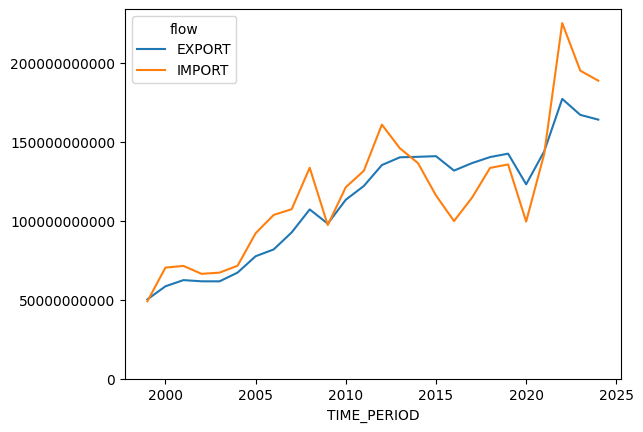

In [12]:
# Export: EU > Africa
# Import: EU < AFrica

df_all_brief.groupby(['TIME_PERIOD', 'flow'])['OBS_VALUE'].sum().unstack('flow').plot()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim(ymin=0)
plt.show()

In [13]:
df_exp_imp_all = df_all_brief.groupby(['TIME_PERIOD', 'flow'])['OBS_VALUE'].sum().unstack('flow').reset_index()
df_exp_imp_all.to_csv('expImpAll.csv', index=False)

#### ACP countries and non-ACP countries

In [14]:
# https://www.oacps.org/member-states/
acp_countries = ["Benin", "Burkina Faso", "Cape Verde", "Cabo Verde", "Gambia", "Ghana", "Guinea", "Guinea-Bissau",
                 "Ivory Coast", "CÃ´te dâIvoire (Ivory Coast)", "Liberia", "Mali", "Mauritania", "Niger", "Nigeria", "Senegal",
                 "Sierra Leone", "Togo", "Cameroon", "Central African Republic", "Chad", "Democratic Republic of the Congo", "Congo, Democratic Republic of",
                 "Republic of the Congo", "Congo", "Equatorial Guinea", "Gabon", "Sao Tome and Principe", "Burundi",
                 "Kenya", "Rwanda", "South Sudan", "Tanzania", "Tanzania, United Republic of", "Uganda", "Comoros", "Comoros (incl. Mayotte 'YT' -> 1976)", "Djibouti", "Eritrea", 
                 "Ethiopia", "Ethiopia (incl. Eritrea 'ER' -> 1993)", "Madagascar", "Malawi", "Mauritius", "Seychelles", "Somalia", "Sudan", "Sudan (incl. South Sudan 'SS' -> 2012)", "Zambia", "Zimbabwe",
                 "Angola", "Botswana", "Eswatini", "Eswatini (Ngwane)", "Lesotho", "Mozambique", "Namibia", "South Africa", "South Africa (incl. Namibia 'NA' -> 1989)", "Mauritania (incl. Spanish Sahara from 1977)"]

In [15]:
df_acp = df_all_brief[df_all_brief['partner'].isin(acp_countries)]
df_no_acp = df_all_brief[~df_all_brief['partner'].isin(acp_countries)]

In [16]:
df_no_acp['partner'].value_counts()

partner
Tunisia    5017
Morocco    5010
Egypt      4979
Algeria    4646
Libya      4033
Name: count, dtype: int64

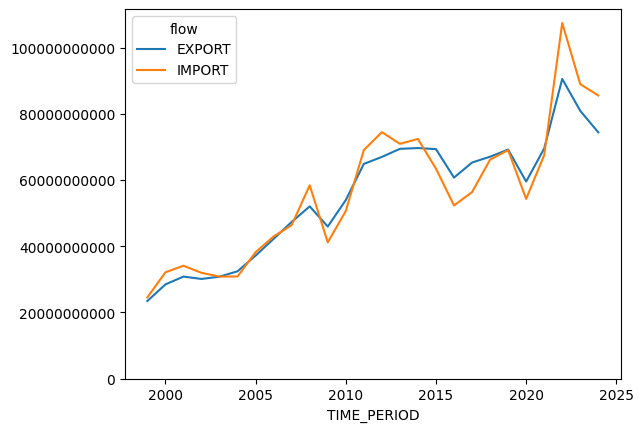

In [17]:
# ACP countries

df_acp.groupby(['TIME_PERIOD', 'flow'])['OBS_VALUE'].sum().unstack('flow').plot()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim(ymin=0)
plt.show()

In [18]:
df_exp_imp_acp = df_acp.groupby(['TIME_PERIOD', 'flow'])['OBS_VALUE'].sum().unstack('flow').reset_index()
df_exp_imp_acp.to_csv('expImpAcp.csv', index=False)

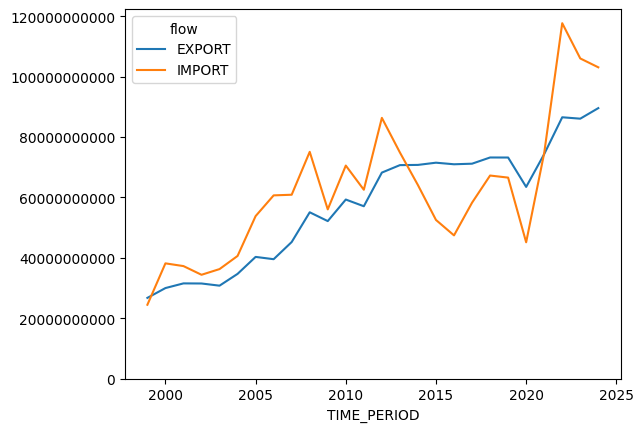

In [19]:
# No ACP countries

df_no_acp.groupby(['TIME_PERIOD', 'flow'])['OBS_VALUE'].sum().unstack('flow').plot()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim(ymin=0)
plt.show()

In [20]:
df_exp_imp_no_acp = df_no_acp.groupby(['TIME_PERIOD', 'flow'])['OBS_VALUE'].sum().unstack('flow').reset_index()
df_exp_imp_no_acp.to_csv('expImpNoAcp.csv', index=False)

## Trade balance

In [21]:
df_trade = (df_all_brief
          .groupby(['partner', 'TIME_PERIOD', 'flow'])['OBS_VALUE']
          .mean()
          .unstack('flow')  # Pivot flow to columns
          .eval('IMPORT - EXPORT') #IMPORT - EXPORT para tener la perspectiva de Africa
          .reset_index(name='trade_balance'))  # Calculate difference


#### Only 2024 for map

In [22]:
df_trade_time = df_trade[df_trade['TIME_PERIOD'] == 2024]

In [23]:
df_trade_time['trade_balance'].sum()

np.float64(480107292.3894472)

In [24]:
df_trade_time.to_csv("tradeStack_2024.csv", index=False)

## By product category

In [25]:
df_products = (df_all_brief
          .groupby(['product', 'TIME_PERIOD', 'flow', 'SourceNumber'])['OBS_VALUE']
          .mean()
          .unstack('flow')  # Pivot flow to columns
          .eval('IMPORT - EXPORT') #IMPORT - EXPORT to get Africa's POV
          .reset_index(name='trade_balance'))  # Calculate difference

In [26]:
df_products_export = df_all_brief[df_all_brief['flow'] == 'IMPORT'].pivot_table(
    index='TIME_PERIOD', 
    columns='product',
    values='OBS_VALUE').reset_index()

#### Which were the top 5 exported products (Africa > EU) in 2024?

In [27]:
df_products_export[df_products_export['TIME_PERIOD'] == 2024].max().sort_values(ascending=False).head(5)

product
MINERAL FUELS, MINERAL OILS AND PRODUCTS OF THEIR DISTILLATION; BITUMINOUS SUBSTANCES; MINERAL WAXES                                                                                       1.869809e+09
COCOA AND COCOA PREPARATIONS                                                                                                                                                               2.951905e+08
VEHICLES OTHER THAN RAILWAY OR TRAMWAY ROLLING STOCK, AND PARTS AND ACCESSORIES THEREOF                                                                                                    2.401399e+08
ELECTRICAL MACHINERY AND EQUIPMENT AND PARTS THEREOF; SOUND RECORDERS AND REPRODUCERS, TELEVISION IMAGE AND SOUND RECORDERS AND REPRODUCERS, AND PARTS AND ACCESSORIES OF SUCH ARTICLES    2.064368e+08
NATURAL OR CULTURED PEARLS, PRECIOUS OR SEMI-PRECIOUS STONES, PRECIOUS METALS, METALS CLAD WITH PRECIOUS METAL, AND ARTICLES THEREOF; IMITATION JEWELLERY; COIN                            1.332

In [28]:
exportProductsTop5 = df_products_export[['TIME_PERIOD', 'MINERAL FUELS, MINERAL OILS AND PRODUCTS OF THEIR DISTILLATION; BITUMINOUS SUBSTANCES; MINERAL WAXES',
                    'COCOA AND COCOA PREPARATIONS',
                    'VEHICLES OTHER THAN RAILWAY OR TRAMWAY ROLLING STOCK, AND PARTS AND ACCESSORIES THEREOF',
                    'ELECTRICAL MACHINERY AND EQUIPMENT AND PARTS THEREOF; SOUND RECORDERS AND REPRODUCERS, TELEVISION IMAGE AND SOUND RECORDERS AND REPRODUCERS, AND PARTS AND ACCESSORIES OF SUCH ARTICLES',
                    'NATURAL OR CULTURED PEARLS, PRECIOUS OR SEMI-PRECIOUS STONES, PRECIOUS METALS, METALS CLAD WITH PRECIOUS METAL, AND ARTICLES THEREOF; IMITATION JEWELLERY; COIN']]

#### 2024 only and preparation for chart

In [29]:
df_products_export_2024 = df_products_export[df_products_export["TIME_PERIOD"] == 2024]

In [30]:
to_exclude = ['TIME_PERIOD', 'MINERAL FUELS, MINERAL OILS AND PRODUCTS OF THEIR DISTILLATION; BITUMINOUS SUBSTANCES; MINERAL WAXES',
                    'COCOA AND COCOA PREPARATIONS',
                    'VEHICLES OTHER THAN RAILWAY OR TRAMWAY ROLLING STOCK, AND PARTS AND ACCESSORIES THEREOF',
                    'ELECTRICAL MACHINERY AND EQUIPMENT AND PARTS THEREOF; SOUND RECORDERS AND REPRODUCERS, TELEVISION IMAGE AND SOUND RECORDERS AND REPRODUCERS, AND PARTS AND ACCESSORIES OF SUCH ARTICLES',
                    'NATURAL OR CULTURED PEARLS, PRECIOUS OR SEMI-PRECIOUS STONES, PRECIOUS METALS, METALS CLAD WITH PRECIOUS METAL, AND ARTICLES THEREOF; IMITATION JEWELLERY; COIN']

In [31]:
# We group all categories that are not on the top 5 exports in 'Other goods'
df_products_export_2024['Other goods'] = df_products_export_2024.drop(columns=to_exclude).sum(axis=1)

/var/folders/0b/lwphr3h568z_g3fjt9hhwx_c0000gs/T/ipykernel_51048/2606736798.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_products_export_2024['Other goods'] = df_products_export_2024.drop(columns=to_exclude).sum(axis=1)


In [32]:
df_products_export_2024_chart = df_products_export_2024[['TIME_PERIOD', 'MINERAL FUELS, MINERAL OILS AND PRODUCTS OF THEIR DISTILLATION; BITUMINOUS SUBSTANCES; MINERAL WAXES',
                    'COCOA AND COCOA PREPARATIONS',
                    'VEHICLES OTHER THAN RAILWAY OR TRAMWAY ROLLING STOCK, AND PARTS AND ACCESSORIES THEREOF',
                    'ELECTRICAL MACHINERY AND EQUIPMENT AND PARTS THEREOF; SOUND RECORDERS AND REPRODUCERS, TELEVISION IMAGE AND SOUND RECORDERS AND REPRODUCERS, AND PARTS AND ACCESSORIES OF SUCH ARTICLES',
                    'NATURAL OR CULTURED PEARLS, PRECIOUS OR SEMI-PRECIOUS STONES, PRECIOUS METALS, METALS CLAD WITH PRECIOUS METAL, AND ARTICLES THEREOF; IMITATION JEWELLERY; COIN', 'Other goods']]

In [33]:
df_products_export_2024_chart.to_csv("productsExported2024.csv")

## Does Africa export primary goods and the EU refined goods?

In [34]:

# We first select and classify chapters based on this 2025 EU Commission report: 
#European Union, Trade in goods with Sub-Saharan Africa
#https://webgate.ec.europa.eu/isdb_results/factsheets/region/details_africa-all-countries_en.pdf

#Imports EU
# V Mineral products: ch 25-27
# IV Foodstuffs, beverages, tobacco: ch. 16-24
# XVII Transport equipment: ch. 86-89
# XVI Machinery and appliances: ch. 84-85
# II Vegetable products: ch. 6-14

#Exports
# XVI Machinery and appliances
# V Mineral products
# VI Products of the chemical or allied industries: ch. 28-38
# XVII Transport equipment
# XV Base metals and articles thereof

# in short:
# II Vegetable products: ch. 6-14 > vegetables and minerals
# IV Foodstuffs, beverages, tobacco: ch. 16-24 > refined goods
# V Mineral products: ch 25-27 > vegetables and minerals
# VI Products of the chemical or allied industries: ch. 28-38 > refined goods
# XV Base metals and articles thereof: chp. 72-83 > refined goods
# XVI Machinery and appliances: ch. 84-85 > refined goods
# XVII Transport equipment: ch. 86-89 > refined goods

In [35]:
vegetables_minerals = ['06', '07', '08', '09', '10', 11, 12, 13, 14, 
                       25, 26, 27]
refined = [16, 17, 18, 19, 20, 21, 22, 23, 24, 
           28, 29, 20, 31, 32, 33, 34, 35, 36, 37, 38, 
           72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 
           84, 85, 
           86, 87, 88, 89]

In [36]:
trade_veg_minerals = df_products[df_products['SourceNumber'].isin(vegetables_minerals)]
trade_veg_minerals = trade_veg_minerals.groupby('TIME_PERIOD')['trade_balance'].sum().reset_index()

In [37]:
refined = df_products[df_products['SourceNumber'].isin(refined)]
refined = refined.groupby('TIME_PERIOD')['trade_balance'].sum().reset_index()

In [38]:
refined = refined.rename(columns={'trade_balance':'refined'})

In [39]:
trade_veg_minerals = trade_veg_minerals.rename(columns={'trade_balance':'vegetables, minerals'})

In [40]:
primary_refined = trade_veg_minerals.merge(refined, on='TIME_PERIOD', how='outer')

In [41]:
primary_refined.to_csv('primaryRefined.csv', index=False)